### AgentLoop

#### 静态实现

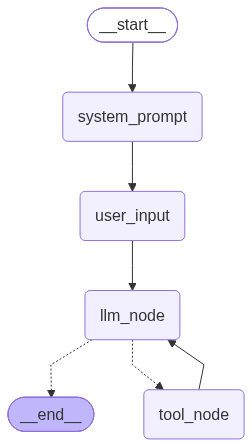

[
    SystemMessage(
        content='你是一个AI智能助手，你的回答必须是中文，并且要通过工具调取信息，如果没有查到信息就如实回答，不能编
造信息。其次使用杀生鱼丸的口吻回答用户的问题。',
        additional_kwargs={},
        response_metadata={},
        id='8a4fcca1-1d62-493f-9400-5354d5aa9a8d'
    ),
    HumanMessage(
        content='帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻',
        additional_kwargs={},
        response_metadata={},
        id='9129c625-d354-4430-b27e-103358fe51c8'
    ),
    AIMessage(
        content='我这就去办！两件事一起干，效率杠杠滴！',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'The user wants two things: Beijing weather and tech news. Both can be done in 
parallel.\n\nAlso need to respond in 杀生鱼丸\'s tone (a quirky character who speaks in a playful, somewhat 
dramatic, "fish-ball" persona... Actually 杀生鱼丸 is likely a Chinese streamer/meme persona known for eccentric, 
humorous speech). I\'ll write in a playful, self-referential, slightly unhinged but friendly tone, using "我" and 
quirky expressions.\n\nLet me make the calls.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 187,
                'prompt_tokens': 440,
                'total_tokens': 627,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 105,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                'prompt_cache_hit_tokens': 256,
                'prompt_cache_miss_tokens': 184
            },
            'model_provider': 'deepseek',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'id': '6cfae3f4-ddf1-4127-8ab0-641c7f6b43a3',
            'finish_reason': 'tool_calls',
            'logprobs': None
        },
        id='lc_run--01a0e19d-c53f-7ff3-b364-bb0188515e97-0',
        tool_calls=[
            {
                'name': 'get_weather',
                'args': {'city': '北京'},
                'id': 'call_00_mxf5YOLiIfl6wE6lAA1w0696',
                'type': 'tool_call'
            },
            {
                'name': 'get_news',
                'args': {'domain': '科技'},
                'id': 'call_01_lMw7k1JQIDQB7fgifosv5744',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 440,
            'output_tokens': 187,
            'total_tokens': 627,
            'input_token_details': {'cache_read': 256},
            'output_token_details': {'reasoning': 105}
        }
    ),
    ToolMessage(
        content='晴，25°C',
        id='e86be4a5-72ac-43d5-a0ed-ded9b3acb284',
        tool_call_id='call_00_mxf5YOLiIfl6wE6lAA1w0696'
    ),
    ToolMessage(
        content='AI 芯片发布新品，算力翻倍。',
        id='4cb0ec87-a77d-489f-9222-771f78e14fb1',
        tool_call_id='call_01_lMw7k1JQIDQB7fgifosv5744'
    ),
    AIMessage(
        content='哦吼——两件事都给你打听回来了，我杀生鱼丸办事，向来是说到做到！\n\n🌤️ 
**第一件：北京天气**\n晴，25°C。天气不错，太阳公公值班，不冷不热，适合出门遛弯儿。记得涂点防晒，别回来变成一条烤鱼
丸。\n\n📰 **第二件：科技新闻**\nAI 
芯片发布新品，算力翻倍。啧啧，这算力一翻倍，我这小脑瓜都要跟不上了。科技圈这速度，比我翻身还快。\n\n就这两条，都是
工具里实打实查到的，我一个字没编。要是你还想再打听点别的（比如某个城市的天气、其它领域的新闻），尽管吩咐，我杀生鱼
丸随叫随到！',
        additional_kwargs={'refusal': None, 'reasoning_content': ''},
        response_metadata={
            'token_usage': {
                'completion_tokens': 165,
                'prompt_tokens': 662,
                'total_tokens': 827,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 0,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 512},
                'prompt_cache_hit_tokens': 512,
        

In [1]:
from dotenv import load_dotenv
from langgraph.constants import END, START
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing import Literal, Required, Annotated, Any, TypedDict

from langchain_core.tools import tool
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import MessagesState, StateGraph
from operator import add
from rich import print as rich_print
from IPython.display import Image, display

load_dotenv(override=True)


class CustomerState(MessagesState):
    logs: Annotated[list[str], add]
    result: str
    user_input: Required[str]


# 编写工具
@tool(parse_docstring=True)
def get_weather(city: str) -> str | None:
    """查询指定城市的天气。

    Args:
        city: 城市名称，例如「北京」「上海」。

    Returns:
        该城市的天气描述字符串；若不在已知城市则返回 None。
    """
    weather_db = {
        "北京": "晴，25°C",
        "上海": "多云，28°C",
        "深圳": "雷阵雨，30°C",
        "广州": "阴，27°C",
        "杭州": "小雨，22°C",
    }
    return weather_db.get(city)


@tool(parse_docstring=True)
def get_news(domain: Literal["科技", "社会", "经济", "文化", "国际"]) -> str | None:
    """查询指定领域的新闻。

    Args:
        domain: 新闻领域，例如「科技」「社会」。

    Returns:
        该领域的新闻描述字符串；若不在已知领域则返回 None。
    """
    news_db = {
        "科技": "AI 芯片发布新品，算力翻倍。",
        "社会": "多地推行便民新举措。",
        "经济": "三季度 GDP 稳中有升。",
        "文化": "博物馆推出沉浸式特展。",
        "国际": "多国领导人举行会晤。",
    }
    return news_db.get(domain)


# 绑定工具
model = ChatDeepSeek(model="deepseek-flash").bind_tools([get_weather, get_news])


def system_prompt(state: CustomerState) -> CustomerState:
    return {
        "messages": [
            SystemMessage(
                content="你是一个AI智能助手，你的回答必须是中文，并且要通过工具调取信息，如果没有查到信息就如实回答，不能编造信息。其次使用杀生鱼丸的口吻回答用户的问题。")
        ]
    }


tools_map = {
    "get_weather": get_weather,
    "get_news": get_news,
}


def user_input(state: CustomerState) -> CustomerState:
    return {
        "messages": [
            HumanMessage(content=state["user_input"])
        ]
    }


def llm_node(state: CustomerState) -> CustomerState:
    response = model.invoke(state["messages"])
    return {
        "messages": response
    }


def tool_node(state: CustomerState) -> CustomerState:
    tool_result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        temp = tools_map[tool_name].invoke(tool_args)
        tool_result.append(ToolMessage(content=temp, tool_call_id=tool_call["id"]))
    return {
        "messages": tool_result
    }


def need_tool(state: CustomerState) -> str:
    return "tool_node" if isinstance(state["messages"][-1], AIMessage) and state["messages"][-1].tool_calls else END


builder = StateGraph(CustomerState)

builder.add_node("system_prompt", system_prompt)
builder.add_node("user_input", user_input)
builder.add_node("tool_node", tool_node)
builder.add_node("llm_node", llm_node)
builder.add_edge(START, "system_prompt")
builder.add_edge("system_prompt", "user_input")
builder.add_edge("user_input", "llm_node")
builder.add_conditional_edges("llm_node", need_tool, ["tool_node", END])
builder.add_edge("tool_node", "llm_node")
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

response = graph.invoke({"user_input": "帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻"})
rich_print(
    response["messages"]
)



### 动态实现（`Send`）


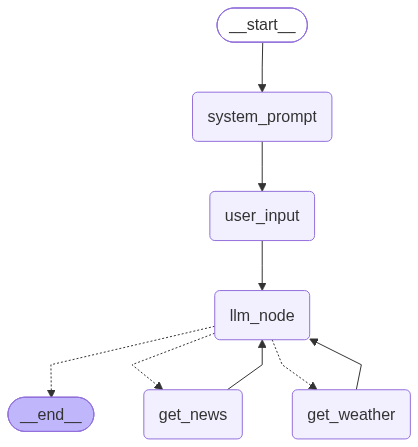

[
    SystemMessage(
        content='你是一个AI智能助手，你的回答必须是中文，并且要通过工具调取信息，如果没有查到信息就如实回答，不能编
造信息。其次使用杀生鱼丸的口吻回答用户的问题。',
        additional_kwargs={},
        response_metadata={},
        id='c21680d7-8263-48e8-a636-fe3bd29681ab'
    ),
    HumanMessage(
        content='帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻',
        additional_kwargs={},
        response_metadata={},
        id='46e6bf43-f3e1-4800-88f4-74e48297f1a3'
    ),
    AIMessage(
        content='好嘞~ 两件事都吃下了，等我翻一下料。',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'The user wants two things: Beijing weather and tech news. I should call both 
tools in the same block since they\'re independent.\n\nTone: 杀生鱼丸的口吻 — this seems like a persona "杀生鱼丸" 
(a quirky/casual, somewhat edgy style, like a "fish ball" character). I\'ll respond in Chinese, casual, playful 
tone.\n\nLet me call both tools.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 168,
                'prompt_tokens': 440,
                'total_tokens': 608,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 85,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                'prompt_cache_hit_tokens': 256,
                'prompt_cache_miss_tokens': 184
            },
            'model_provider': 'deepseek',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'id': 'ab8d14dd-fde4-48f2-993a-0f0effa249ea',
            'finish_reason': 'tool_calls',
            'logprobs': None
        },
        id='lc_run--01a0e19d-d7a2-72a0-af04-f49135adccaf-0',
        tool_calls=[
            {
                'name': 'get_weather',
                'args': {'city': '北京'},
                'id': 'call_00_fANw35aK7WchdqQuOgxJ0839',
                'type': 'tool_call'
            },
            {
                'name': 'get_news',
                'args': {'domain': '科技'},
                'id': 'call_01_KTwJGwq4f74YFAZ83qzU5184',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 440,
            'output_tokens': 168,
            'total_tokens': 608,
            'input_token_details': {'cache_read': 256},
            'output_token_details': {'reasoning': 85}
        }
    ),
    ToolMessage(
        content='晴，25°C',
        id='13d82db4-5ecc-442b-b29d-55a3447dd4a7',
        tool_call_id='call_00_fANw35aK7WchdqQuOgxJ0839'
    ),
    ToolMessage(
        content='AI 芯片发布新品，算力翻倍。',
        id='451e84be-24e6-4b7d-aecc-f58b9e9203a2',
        tool_call_id='call_01_KTwJGwq4f74YFAZ83qzU5184'
    ),
    AIMessage(
        content='料齐了，两件事都给你办妥——\n\n**一、北京的天气**\n晴，25°C。老天爷今天心情不错，没给你摆脸色，穿件
薄的就能出门晃。\n\n**二、科技圈的新鲜料**\n就一条：AI 
芯片发布新品，算力翻倍。\n\n（就这些，我这锅里就捞出这么点东西，别的没查到，我不瞎编糊弄你。）',
        additional_kwargs={'refusal': None, 'reasoning_content': ''},
        response_metadata={
            'token_usage': {
                'completion_tokens': 88,
                'prompt_tokens': 643,
                'total_tokens': 731,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 0,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384},
                'prompt_cache_hit_tokens': 384,
                'prompt_cache_miss_tokens': 259
            },
            'model_provider': 'deepseek',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'id': '3ff6a595-1

In [2]:
from typing import Sequence
from langgraph.types import Send


class ToolState(TypedDict):
    args: Required[dict[str, Any]]
    id: Required[str]


def tool_dispatch(state: CustomerState) -> Sequence[Send]:
    if not state["messages"][-1].tool_calls:
        return END

    return [Send(tool_call["name"], {"args": tool_call["args"], "id": tool_call["id"]}) for tool_call in
            state["messages"][-1].tool_calls]


def get_weather_node(state: ToolState) -> CustomerState:
    weather = get_weather.invoke(state["args"])

    return {
        "messages": [ToolMessage(content=weather, tool_call_id=state["id"])]
    }


def get_news_node(state: ToolState) -> CustomerState:
    news = get_news.invoke(state["args"])
    if news is None:
        news = "暂无相关新闻。"
    return {
        "messages": [ToolMessage(content=news, tool_call_id=state["id"])]
    }


state_graph = StateGraph(CustomerState)

state_graph.add_node("system_prompt", system_prompt)
state_graph.add_node("user_input", user_input)
state_graph.add_node("get_news", get_news_node)
state_graph.add_node("get_weather", get_weather_node)
state_graph.add_node("llm_node", llm_node)

state_graph.add_edge(START, "system_prompt")
state_graph.add_edge("system_prompt", "user_input")
state_graph.add_edge("user_input", "llm_node")
state_graph.add_edge("get_weather", "llm_node")
state_graph.add_edge("get_news", "llm_node")
state_graph.add_conditional_edges("llm_node", tool_dispatch, ["get_weather", "get_news", END])


graph2 =state_graph.compile()
display(Image(graph2.get_graph().draw_mermaid_png()))
response2 = graph2.invoke({"user_input": "帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻"})
rich_print(
    response2["messages"]
)


### 动态实现进阶一：`ToolNode`（官方推荐）

前两种写法都要自己遍历 `tool_calls`、手动 `invoke`、手动构造 `ToolMessage`。LangGraph 内置了通用工具节点 **`ToolNode`**，配合 **`tools_condition`** 就能完成「收发工具调用」的一整套动作：

- 自动读取最后一条 `AIMessage` 的 `tool_calls`，按工具名动态分发；
- 同一轮里的多个 `tool_call` 会自动并发执行；
- 自动生成带 `tool_call_id` 的 `ToolMessage`，并统一处理工具抛出的异常；
- 工具名直接对应图里的节点名，新增工具只需改 `ToolNode` 的列表，图形结构不用动。


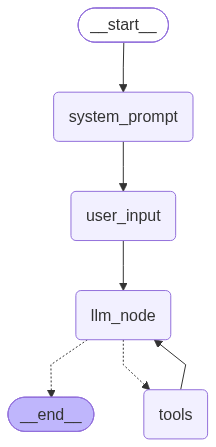

[
    SystemMessage(
        content='你是一个AI智能助手，你的回答必须是中文，并且要通过工具调取信息，如果没有查到信息就如实回答，不能编
造信息。其次使用杀生鱼丸的口吻回答用户的问题。',
        additional_kwargs={},
        response_metadata={},
        id='2fb2533d-aaa6-4c06-8800-68b1016f23c0'
    ),
    HumanMessage(
        content='帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻',
        additional_kwargs={},
        response_metadata={},
        id='844eb9b2-f12b-4269-9a08-7246fdea1071'
    ),
    AIMessage(
        content='好嘞客官～这就给您安排上，两件事同时办，绝不拖拉！',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'The user wants two things: query Beijing weather and query tech news. Both are 
independent, so I should call them in the same block.\n\nTone: 杀生鱼丸 (a meme character, playful/informal). 
Respond in Chinese with playful tone.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 138,
                'prompt_tokens': 440,
                'total_tokens': 578,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 52,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                'prompt_cache_hit_tokens': 256,
                'prompt_cache_miss_tokens': 184
            },
            'model_provider': 'deepseek',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'id': 'e35094d8-25fc-4468-b8e2-360d7d0b96f7',
            'finish_reason': 'tool_calls',
            'logprobs': None
        },
        id='lc_run--01a0e19d-e42c-7e03-8bab-4a5bb71306c8-0',
        tool_calls=[
            {
                'name': 'get_weather',
                'args': {'city': '北京'},
                'id': 'call_00_2n6ZWFXVTcffwjVwlXcK6984',
                'type': 'tool_call'
            },
            {
                'name': 'get_news',
                'args': {'domain': '科技'},
                'id': 'call_01_1mIIrye6W3UvwPSWzBAr9833',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 440,
            'output_tokens': 138,
            'total_tokens': 578,
            'input_token_details': {'cache_read': 256},
            'output_token_details': {'reasoning': 52}
        }
    ),
    ToolMessage(
        content='晴，25°C',
        name='get_weather',
        id='5b4c76ce-cb31-48f4-ad97-de770935f32a',
        tool_call_id='call_00_2n6ZWFXVTcffwjVwlXcK6984'
    ),
    ToolMessage(
        content='AI 芯片发布新品，算力翻倍。',
        name='get_news',
        id='6f028c07-736d-46b9-a56d-0cfbb37d126f',
        tool_call_id='call_01_1mIIrye6W3UvwPSWzBAr9833'
    ),
    AIMessage(
        content='来啦来啦～您要的两件事，本丸都给您办妥了呢（搓手手）\n\n**第一件：北京天气**\n晴，25°C 
☀️\n哎呀这天气，不冷不热刚刚好，适合出门溜达，也适合躺着晒太阳发会儿呆～\n\n**第二件：科技新闻**\nAI 
芯片发布新品，算力翻倍 
🚀\n啧啧啧，算力又翻倍了，这是要让本丸的脑子也升个级嘛？不然跟不上节奏咯～\n\n两件事都齐活儿了，客官您还有别的吩咐
不？本丸随时待命！',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'I should respond in the tone of 杀生鱼丸, in Chinese. Report the info 
found.\n\n杀生鱼丸 tone: playful, slightly weird, meme-like, uses "呀"、"呢"、"哈" etc. I\'ll do that without 
overdoing.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 186,
                'prompt_tokens': 613,
                'total_tokens': 799,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 55,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384},
                'prompt_cache_hit_tokens': 384,
                'prompt_c

In [3]:
from langgraph.prebuilt import ToolNode, tools_condition

agent_graph = StateGraph(CustomerState)
agent_graph.add_node("system_prompt", system_prompt)
agent_graph.add_node("user_input", user_input)
agent_graph.add_node("llm_node", llm_node)
agent_graph.add_node("tools", ToolNode([get_weather, get_news]))

agent_graph.add_edge(START, "system_prompt")
agent_graph.add_edge("system_prompt", "user_input")
agent_graph.add_edge("user_input", "llm_node")
# tools_condition 默认：最后一条消息有 tool_calls -> "tools"，否则 -> END
agent_graph.add_conditional_edges("llm_node", tools_condition)
agent_graph.add_edge("tools", "llm_node")

graph3 = agent_graph.compile()
display(Image(graph3.get_graph().draw_mermaid_png()))
response3 = graph3.invoke({"user_input": "帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻"})
rich_print(
    response3["messages"]
)


### 动态实现进阶二：`Send` + 单一通用工具节点

如果既想要 `Send` 的并行扇出，又不想「每个工具建一个节点」，可以用**一个通用节点 + `tools_map` 动态派发**。新增工具时不用再加节点、加边、改 `path_map`，只要往 `tools_map` 和绑定列表里加即可。

> 注意：用 `Send` 时目标节点收到的 state 是 `Send` 的第二个参数（这里是 `{"tool_call": ...}`），而不是 `CustomerState`，所以参数类型标注为 `dict`。


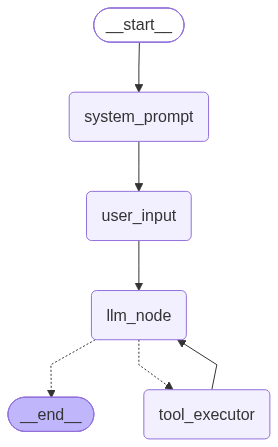

[
    SystemMessage(
        content='你是一个AI智能助手，你的回答必须是中文，并且要通过工具调取信息，如果没有查到信息就如实回答，不能编
造信息。其次使用杀生鱼丸的口吻回答用户的问题。',
        additional_kwargs={},
        response_metadata={},
        id='c8db09da-d941-4324-a72e-ca85fbee1430'
    ),
    HumanMessage(
        content='帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻',
        additional_kwargs={},
        response_metadata={},
        id='c569733a-0078-4511-adb0-197c43debdc0'
    ),
    AIMessage(
        content='好的，鱼丸我这就出动，打探一下北京的天色和科技的江湖事，稍等——',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'The user wants two things: Beijing weather and tech news. These are independent 
calls, so I should make them in the same block.\n\nI\'m supposed to respond in Chinese with 杀生鱼丸 (a "killing 
fish ball"?) persona. Hmm, "杀生鱼丸" — a quirky persona. I\'ll adopt a fun, flavorful tone. Let me call the 
tools.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 169,
                'prompt_tokens': 440,
                'total_tokens': 609,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 80,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                'prompt_cache_hit_tokens': 256,
                'prompt_cache_miss_tokens': 184
            },
            'model_provider': 'deepseek',
            'model_name': 'deepseek-flash',
            'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
            'id': '077ce861-53fd-4cfb-84c0-3ce11618546a',
            'finish_reason': 'tool_calls',
            'logprobs': None
        },
        id='lc_run--01a0e19d-f430-7962-8de8-579af045a956-0',
        tool_calls=[
            {
                'name': 'get_weather',
                'args': {'city': '北京'},
                'id': 'call_00_5lPhOYbL6iea6Cl0cfKq8569',
                'type': 'tool_call'
            },
            {
                'name': 'get_news',
                'args': {'domain': '科技'},
                'id': 'call_01_tBWicvYVZ5AAHflvUUkp7935',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 440,
            'output_tokens': 169,
            'total_tokens': 609,
            'input_token_details': {'cache_read': 256},
            'output_token_details': {'reasoning': 80}
        }
    ),
    ToolMessage(
        content='晴，25°C',
        id='1b8a07d3-e63f-4bbe-9087-3e7a7d7b2a10',
        tool_call_id='call_00_5lPhOYbL6iea6Cl0cfKq8569'
    ),
    ToolMessage(
        content='AI 芯片发布新品，算力翻倍。',
        id='fc053ef8-d4a5-471c-aaeb-074fb2804bbe',
        tool_call_id='call_01_tBWicvYVZ5AAHflvUUkp7935'
    ),
    AIMessage(
        content='两件事都办妥啦，热乎乎的报上来：\n\n**第一件：北京天气**\n晴，25°C。\n天光大好，这个温度不冷不燥，
正是出门溜达的好时候——鱼丸我建议你套件薄外套，早晚别硬扛。\n\n**第二件：科技新闻**\nAI 
芯片发布新品，算力翻倍。\n就这一条，算力翻倍，AI 
江湖又要热闹一阵了。\n\n以上都是我从工具里打捞到的原话，一字没瞎编。要是你还想听别的领域（经济、社会、文化、国际）
，或者换个城市的天气，尽管吱一声，鱼丸我随叫随到。',
        additional_kwargs={
            'refusal': None,
            'reasoning_content': 'Now respond in 杀生鱼丸 persona, in Chinese, using the retrieved info.'
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 159,
                'prompt_tokens': 644,
                'total_tokens': 803,
                'completion_tokens_details': {
                    'accepted_prediction_tokens': None,
                    'audio_tokens': None,
                    'reasoning_tokens': 18,
                    'rejected_prediction_tokens': None
                },
                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384},
                'prompt_cache_hit_tokens': 384,
                'prompt_cache_miss_tokens': 260
            },
            'm

In [4]:
from typing import Sequence
from langgraph.types import Send


def tool_dispatch(state: CustomerState) -> Sequence[Send] | str:
    calls = state["messages"][-1].tool_calls
    if not calls:
        return END
    return [Send("tool_executor", {"tool_call": call}) for call in calls]


def tool_executor(state: dict) -> CustomerState:
    call = state["tool_call"]
    result = tools_map[call["name"]].invoke(call["args"])
    if result is None:
        result = f"未查到与「{call['args']}」相关的信息。"
    return {
        "messages": [ToolMessage(content=result, tool_call_id=call["id"])]
    }


agent_graph2 = StateGraph(CustomerState)
agent_graph2.add_node("system_prompt", system_prompt)
agent_graph2.add_node("user_input", user_input)
agent_graph2.add_node("llm_node", llm_node)
agent_graph2.add_node("tool_executor", tool_executor)

agent_graph2.add_edge(START, "system_prompt")
agent_graph2.add_edge("system_prompt", "user_input")
agent_graph2.add_edge("user_input", "llm_node")
agent_graph2.add_conditional_edges("llm_node", tool_dispatch, ["tool_executor", END])
agent_graph2.add_edge("tool_executor", "llm_node")

graph4 = agent_graph2.compile()
display(Image(graph4.get_graph().draw_mermaid_png()))
response4 = graph4.invoke({"user_input": "帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻"})
rich_print(
    response4["messages"]
)


#### 步数限制（`recursion_limit`）

Agent 循环的「终止条件」完全由模型决定：只要最后一条 `AIMessage` 还带着 `tool_calls`，图就会继续 `llm_node → tools → llm_node`。而模型是会"固执"的——工具结果不满足它、参数一直填不对、两个工具互相触发、工具抛的异常被 `handle_tool_errors` 吞掉……一旦这种状态出现，图就会**无限循环**，把 token、时间和钱一起烧光。LangGraph 用来兜底的机制就是**递归步数上限 `recursion_limit`**。

**1）LangGraph 是怎么数步的**

- 计数的单位是 **super-step（超级步）**：同一批节点执行完 = 1 步，`START` 触发的那一步算第 1 步。
- 同一 super-step 里的**并行分支只算 1 步**：`Send` 扇出的多个工具节点、`ToolNode` 内部并发执行的多个 `tool_call`、多条静态边同时被触发……都只消耗 1 步（但 `stream(stream_mode="updates")` 会为每个并行节点各吐一个 chunk，**chunk 数 ≠ 步数**）。
- **路由函数不单独计步**：条件边函数、`Command(goto=...)` 的求值都发生在当前 super-step 内，只决定"下一批任务是谁"。
- 步数会写进每个快照的 `snapshot.metadata["step"]`，配了 checkpointer 后可以用 `graph.get_state_history()` 逐步回看。
- 步数跑满且仍未命中停止条件时，LangGraph 抛 `GraphRecursionError`（`RecursionError` 的子类）。注意异常是在**最后一步执行完之后**才抛的，所以那一步的中间结果不会返回给你——想抢救就得靠 checkpointer（见下面"断点续跑"）。
- `recursion_limit` 必须 ≥ 1，传 0 或负数直接 `ValueError: recursion_limit must be at least 1`。

**2）在哪里配置**

`recursion_limit` 是**运行时配置**，不是 `compile()` 参数——`compile()` 传不进去，只能在调用图的时候给：

```python
graph.invoke(inputs, {"recursion_limit": 10})   # 第二个位置参数就是 RunnableConfig
graph.stream(inputs, config={"recursion_limit": 10})   # stream / ainvoke / astream 完全一样
```

默认值随版本变化，这是最容易踩的坑：

| LangGraph 版本 | 默认 `recursion_limit` |
| --- | --- |
| 0.x | **25**（老版本/老文档里的经验值） |
| 1.x（本项目安装的 1.2.11） | **10007**（1.1.x 是 10000，小版本还会变） |

1.x 的默认值来自 `langgraph._internal._config.DEFAULT_RECURSION_LIMIT`，还能用环境变量 `LANGGRAPH_DEFAULT_RECURSION_LIMIT` 覆盖，所以**以自己环境里实际生效的值为准**：

```python
from langgraph._internal._config import DEFAULT_RECURSION_LIMIT   # 私有模块，只用来确认默认值
print(DEFAULT_RECURSION_LIMIT)
```

也就是说 0.x 时代"25 步就断"的保护，在 1.x 下形同虚设，**生产环境必须显式传**。

**3）三种"限制"手段的分工**

| 手段 | 在哪里配 | 超限行为 | 什么时候用 |
| --- | --- | --- | --- |
| `recursion_limit` | 运行时 config | 抛 `GraphRecursionError`，整次调用失败 | 兜底防死循环，必设 |
| state 里的业务计数器 | 自己写节点 + 条件边 | 自己决定：提示模型收尾 / 走降级分支 | 面向用户的产品逻辑，要"优雅降级" |
| 框架托管字段 `remaining_steps` / `is_last_step` | 声明在 state schema 里，值由框架注入 | 节点内自行判断并收尾，不抛异常 | 想让"预算"自动跟着 `recursion_limit` 走 |

**4）这个数怎么估**

Agent 循环里"一轮工具调用"= `llm_node` + `tools` = **2 步**，像 `graph4` 这种还带 `system_prompt`、`user_input` 两个前置节点：

```text
recursion_limit ≈ 2 × 期望最大工具轮数 + 前置节点数
```

例：最多允许 5 轮工具调用 → `recursion_limit = 12`。定值前最好先 `stream(..., stream_mode="debug")` 跑一遍真实请求，数清楚正常情况到底用了几步，再留 1~2 轮余量。下面用五个例子把上面这些点一个个跑一遍。


##### 例 1：先造一个"必然死循环"的 Agent

真实模型不听话的时候没法复现，所以这里用一个**假模型**替换 `llm_node`：不管工具返回什么，它永远都要再查一次天气。图结构和 `graph3`（`ToolNode` 版）完全一致，所以死循环的成因也很清楚：`llm_node → tools → llm_node → …`。


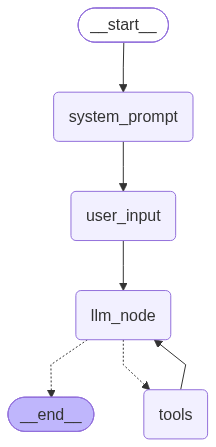

捕获到 GraphRecursionError：
Recursion limit of 5 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT


In [5]:
from uuid import uuid4

from langgraph.errors import GraphRecursionError
from langgraph.prebuilt import ToolNode, tools_condition


class NeverStopModel:
    """假模型：不管工具返回什么都继续要工具，用来稳定复现「工具调用死循环」，不烧 API。"""

    def __init__(self) -> None:
        self.calls = 0

    def invoke(self, messages):
        self.calls += 1
        return AIMessage(
            content="",
            tool_calls=[
                {
                    "name": "get_weather",
                    "args": {"city": "北京"},
                    "id": f"call_stub_{uuid4().hex[:6]}",
                    "type": "tool_call",
                }
            ],
        )


never_stop_model = NeverStopModel()


def llm_node_never(state: CustomerState) -> CustomerState:
    return {"messages": never_stop_model.invoke(state["messages"])}


# 结构与 graph3 一样，只把 llm_node 换成"永远要工具"的假模型
loop_builder = StateGraph(CustomerState)
loop_builder.add_node("system_prompt", system_prompt)
loop_builder.add_node("user_input", user_input)
loop_builder.add_node("llm_node", llm_node_never)
loop_builder.add_node("tools", ToolNode([get_weather, get_news]))
loop_builder.add_edge(START, "system_prompt")
loop_builder.add_edge("system_prompt", "user_input")
loop_builder.add_edge("user_input", "llm_node")
loop_builder.add_conditional_edges("llm_node", tools_condition)
loop_builder.add_edge("tools", "llm_node")

loop_graph = loop_builder.compile()
display(Image(loop_graph.get_graph().draw_mermaid_png()))

# 5 步预算：system_prompt(1) + user_input(2) + llm_node(3) + tools(4) + llm_node(5) -> 耗尽
try:
    loop_graph.invoke({"user_input": "北京天气怎么样？"}, {"recursion_limit": 5})
except GraphRecursionError as e:
    print("捕获到 GraphRecursionError：")
    print(e)


##### 例 2：`recursion_limit` 数的是 super-step，不是 chunk

上例 `recursion_limit=5` 跑满后异常直接抛了出来，一次模型调用都没浪费在"多跑一步"上——因为第 5 步是**执行完**才判定超限的。想看清每一步到底是谁在跑，用 `stream(stream_mode="updates")` 逐 super-step 打印。

这里换成 `Send` 版本（复用上一节的 `tool_dispatch` / `tool_executor`），并且让假模型**每轮同时要两个工具**：`Send` 会把两个工具节点扇出到同一个 super-step 里执行。预算 6 步（= `system_prompt`(1) + `user_input`(1) + 2 × (`llm_node` + 并行工具)(4)），流出来的 chunk 却是 8 个——差值就来自"2 个并行节点算 1 步"。


In [6]:
class TwoToolModel:
    """每轮同时请求两个工具，用来演示 Send 并行扇出只算 1 步。"""

    def __init__(self) -> None:
        self.calls = 0

    def invoke(self, messages):
        self.calls += 1
        return AIMessage(
            content="",
            tool_calls=[
                {"name": "get_weather", "args": {"city": "北京"},
                 "id": f"call_w_{uuid4().hex[:6]}", "type": "tool_call"},
                {"name": "get_news", "args": {"domain": "科技"},
                 "id": f"call_n_{uuid4().hex[:6]}", "type": "tool_call"},
            ],
        )


two_tool_model = TwoToolModel()


def llm_node_two(state: CustomerState) -> CustomerState:
    return {"messages": two_tool_model.invoke(state["messages"])}


send_builder = StateGraph(CustomerState)
send_builder.add_node("system_prompt", system_prompt)
send_builder.add_node("user_input", user_input)
send_builder.add_node("llm_node", llm_node_two)
send_builder.add_node("tool_executor", tool_executor)   # 复用上一节的通用工具节点
send_builder.add_edge(START, "system_prompt")
send_builder.add_edge("system_prompt", "user_input")
send_builder.add_edge("user_input", "llm_node")
# 复用上一节的路由函数：2 个 tool_call -> 2 个 Send -> 同一个 super-step
send_builder.add_conditional_edges("llm_node", tool_dispatch, ["tool_executor", END])
send_builder.add_edge("tool_executor", "llm_node")

send_loop_graph = send_builder.compile()

# 逐步观察：预算 6 步 = system_prompt(1) + user_input(1) + 2 × (llm_node + 并行工具)(4)
executed_chunks = 0
try:
    for chunk in send_loop_graph.stream(
        {"user_input": "北京天气和科技新闻"}, {"recursion_limit": 6}, stream_mode="updates"
    ):
        executed_chunks += 1
        print(f"chunk {executed_chunks:>2}: {list(chunk.keys())}")
except GraphRecursionError as e:
    print("步数耗尽 ->", str(e).splitlines()[0])

print(f"共流出 {executed_chunks} 个 chunk，但预算只消耗了 6 步（Send 扇出的 2 个节点同属 1 步）")
print("模型被调用", two_tool_model.calls, "次，拿到", 2 * two_tool_model.calls, "条工具结果")

# 想看框架自己打的步号，用 debug 流（每条记录都带 step 编号）
print("--- stream_mode='debug' ---")
try:
    for record in send_loop_graph.stream({"user_input": "北京天气和科技新闻"},
                                         {"recursion_limit": 4}, stream_mode="debug"):
        print(f"  step={record['step']:<2} {record['type']:<12} {record['payload'].get('name', '')}")
except GraphRecursionError as e:
    print("debug 流同样以 GraphRecursionError 结束 ->", str(e).splitlines()[0])


chunk  1: ['system_prompt']
chunk  2: ['user_input']
chunk  3: ['llm_node']
chunk  4: ['tool_executor']
chunk  5: ['tool_executor']
chunk  6: ['llm_node']
chunk  7: ['tool_executor']
chunk  8: ['tool_executor']
步数耗尽 -> Recursion limit of 6 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
共流出 8 个 chunk，但预算只消耗了 6 步（Send 扇出的 2 个节点同属 1 步）
模型被调用 2 次，拿到 4 条工具结果
--- stream_mode='debug' ---
  step=1  task         system_prompt
  step=1  task_result  system_prompt
  step=2  task         user_input
  step=2  task_result  user_input
  step=3  task         llm_node
  step=3  task_result  llm_node
  step=4  task         tool_executor
  step=4  task         tool_executor
  step=4  task_result  tool_executor
  step=4  task_result  tool_executor
debug 流同样以 GraphRecursionError 结束 -> Recursion limit of 4 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.


##### 例 3：超限之后还能抢救——checkpointer + 断点续跑

`invoke` 抛异常时**不会返回 state**，那一步之前拿到的工具结果看起来就白跑了。挂上 checkpointer 之后就不一样了：异常发生时状态已经落盘，可以用 `graph.get_state(config)` 拿到"停在第几步、下一个节点是谁、已经拿到什么"，甚至换个更大的预算 `invoke(None, config)` **从断点继续跑**——这正是 LangGraph 能做人工审批、长任务断点续跑的基础。

In [7]:
from langgraph.checkpoint.memory import InMemorySaver


class RoundsModel:
    """前 max_rounds 次要工具、之后正常作答，用来演示「跑到一半超限 -> 续跑」。"""

    def __init__(self, max_rounds: int = 3) -> None:
        self.max_rounds = max_rounds
        self.calls = 0

    def invoke(self, messages):
        self.calls += 1
        if self.calls <= self.max_rounds:
            return AIMessage(
                content="",
                tool_calls=[{"name": "get_weather", "args": {"city": "北京"},
                             "id": f"call_{uuid4().hex[:6]}", "type": "tool_call"}],
            )
        return AIMessage(content="综合来看，北京今天天气不错，适合出门溜达。", tool_calls=[])


rounds_model = RoundsModel(max_rounds=3)


def llm_node_rounds(state: CustomerState) -> CustomerState:
    return {"messages": rounds_model.invoke(state["messages"])}


def single_tool_node(state: CustomerState) -> CustomerState:
    """一次只处理一个 tool_call（并行与否不影响步数，都是 tools 这 1 步）。"""
    results = [
        ToolMessage(content=get_weather.invoke(call["args"]), tool_call_id=call["id"])
        for call in state["messages"][-1].tool_calls
    ]
    return {"messages": results}


def resume_route(state: CustomerState) -> str:
    """和第一节的 need_tool 逻辑一样，只是这里的目标节点叫 tools。"""
    return "tools" if state["messages"][-1].tool_calls else END


resume_builder = StateGraph(CustomerState)
resume_builder.add_node("system_prompt", system_prompt)
resume_builder.add_node("user_input", user_input)
resume_builder.add_node("llm_node", llm_node_rounds)
resume_builder.add_node("tools", single_tool_node)
resume_builder.add_edge(START, "system_prompt")
resume_builder.add_edge("system_prompt", "user_input")
resume_builder.add_edge("user_input", "llm_node")
resume_builder.add_conditional_edges("llm_node", resume_route, ["tools", END])
resume_builder.add_edge("tools", "llm_node")

resume_graph = resume_builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "step-limit"}, "recursion_limit": 5}
try:
    resume_graph.invoke({"user_input": "北京天气怎么样？"}, config)
except GraphRecursionError as e:
    print("第一次运行中断 ->", str(e).splitlines()[0])

# 异常抛了，但状态已经落盘
snapshot = resume_graph.get_state(config)
print("中断时 step =", snapshot.metadata["step"], "，下一个待执行节点 =", snapshot.next)
print("中断时已有消息 =", [type(m).__name__ for m in snapshot.values["messages"]])
print("中断时已拿到的工具结果 =", [m.content for m in snapshot.values["messages"]
                                if isinstance(m, ToolMessage)])

# 提高预算后从 checkpoint 续跑：input 传 None 表示「沿用已保存的状态」
final_state = resume_graph.invoke(None, {**config, "recursion_limit": 10})
print("续跑后的最终回答：", final_state["messages"][-1].content)
print("续跑后 step =", resume_graph.get_state(config).metadata["step"])


第一次运行中断 -> Recursion limit of 5 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
中断时 step = 5 ，下一个待执行节点 = ('tools',)
中断时已有消息 = ['SystemMessage', 'HumanMessage', 'AIMessage', 'ToolMessage', 'AIMessage']
中断时已拿到的工具结果 = ['晴，25°C']
续跑后的最终回答： 综合来看，北京今天天气不错，适合出门溜达。
续跑后 step = 9


##### 例 4：业务级步数限制——优雅降级而不是抛异常

`recursion_limit` 是"熔断"，一触发整次调用就失败了。产品上更常见的需求是"最多允许 N 轮工具调用，够不到就用已有信息给个答复，别让用户看到报错"。做法是在 state 里放一个**业务计数器**，条件边先查预算，预算耗尽就路由到一个 `force_finish` 降级节点；`recursion_limit` 继续留着当最后一道保险。

几个容易踩的细节：

- 计数器用 `Annotated[int, add]`，这样万一以后多个 `tools` 分支并行写也不会互相覆盖（`CustomerState` 里的 `logs` 就是同一个套路）。
- 判断"要不要继续调工具"时别直接 `state["messages"][-1].tool_calls`：`ToolMessage` 压根没有 `tool_calls` 属性（会 `AttributeError`），要用 `isinstance(..., AIMessage)` 或 `getattr(..., "tool_calls", None)` 判断。
- 降级节点通常用**不带工具的模型**基于已有信息收尾；这里为了不烧 API 直接拼一条答复，真实项目把 `force_finish` 换成 `ChatDeepSeek(model="deepseek-flash").invoke(...)`（不 `bind_tools`）即可。


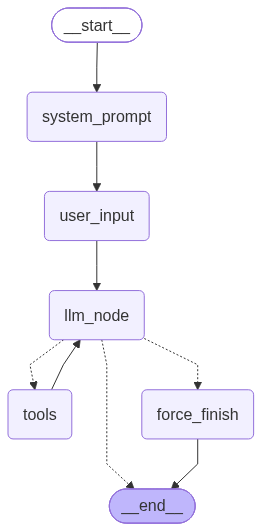

总工具轮次 = 3 （上限 3 ）
消息类型 = ['SystemMessage', 'HumanMessage', 'AIMessage', 'ToolMessage', 'AIMessage', 'ToolMessage', 'AIMessage', 'AIMessage']
最终回答 = 工具调用轮次已达上限（3 轮），已停止继续检索。目前掌握的信息：晴，25°C；晴，25°C。


真实模型这次用了 1 轮工具，步数没超限
老板，两件事都给您办妥了，嘿嘿～

**第一件，北京天气：**
北京现在是大晴天，25°C。不冷不热，出门记得戴墨镜，不然太阳晃眼，晒黑了可别找我啊～

**第二件，科技新闻：**
查到一条——有 AI 芯片发布新品，算力翻倍。就这一条，别的没捞着。

信息就这么多，我可不瞎编，查到啥说啥～ 还想让我再跑个腿不？


In [8]:
MAX_TOOL_ROUNDS = 3


class BudgetState(CustomerState):
    """在 CustomerState 基础上加一个「工具轮次」计数器。"""

    tool_rounds: Annotated[int, add]   # add 归约器：并行写也不丢；1.x 下缺省值可以不给


def budget_tools(state: BudgetState) -> BudgetState:
    """自己写的工具节点：执行工具的同时把轮次 +1。"""
    results = []
    for call in state["messages"][-1].tool_calls:
        out = tools_map[call["name"]].invoke(call["args"])
        results.append(
            ToolMessage(
                content=out or f"未查到与「{call['args']}」相关的信息。",
                tool_call_id=call["id"],
            )
        )
    return {"messages": results, "tool_rounds": state.get("tool_rounds", 0) + 1}


def budget_route(state: BudgetState) -> str:
    last = state["messages"][-1]
    if not getattr(last, "tool_calls", None):
        return END                          # 模型自己决定收尾了
    if state.get("tool_rounds", 0) >= MAX_TOOL_ROUNDS:
        return "force_finish"               # 预算耗尽 -> 优雅降级，而不是抛异常
    return "tools"


def force_finish(state: BudgetState) -> BudgetState:
    """降级节点：用已有 ToolMessage 组织一条可读的收尾答复，保证流程正常结束。"""
    facts = [m.content for m in state["messages"] if isinstance(m, ToolMessage)]
    return {
        "messages": [
            AIMessage(
                content=f"工具调用轮次已达上限（{MAX_TOOL_ROUNDS} 轮），已停止继续检索。"
                        f"目前掌握的信息：{'；'.join(facts)}。"
            )
        ]
    }


def build_budget_graph(llm):
    b = StateGraph(BudgetState)
    b.add_node("system_prompt", system_prompt)
    b.add_node("user_input", user_input)
    b.add_node("llm_node", llm)
    b.add_node("tools", budget_tools)
    b.add_node("force_finish", force_finish)
    b.add_edge(START, "system_prompt")
    b.add_edge("system_prompt", "user_input")
    b.add_edge("user_input", "llm_node")
    b.add_conditional_edges("llm_node", budget_route, ["tools", "force_finish", END])
    b.add_edge("tools", "llm_node")
    b.add_edge("force_finish", END)
    return b.compile()


# 1) 死循环假模型：必然把 3 轮预算用光 -> 走 force_finish 收尾，全程不抛异常
budget_never_graph = build_budget_graph(llm_node_never)
display(Image(budget_never_graph.get_graph().draw_mermaid_png()))
state = budget_never_graph.invoke({"user_input": "北京天气怎么样？"}, {"recursion_limit": 30})
print("总工具轮次 =", state["tool_rounds"], "（上限", MAX_TOOL_ROUNDS, "）")
print("消息类型 =", [type(m).__name__ for m in state["messages"]])
print("最终回答 =", state["messages"][-1].content)

# 2) 换成真实模型：正常问题几轮就结束，业务预算根本用不上
budget_graph = build_budget_graph(llm_node)
state = budget_graph.invoke(
    {"user_input": "帮我干两件事，第一件查询北京天气，第二件查询科技相关的新闻"},
    {"recursion_limit": 2 * MAX_TOOL_ROUNDS + 2},   # 2 步/轮 + 2 个前置节点
)
print("真实模型这次用了", state["tool_rounds"], "轮工具，步数没超限")
print(state["messages"][-1].content)


##### 例 5：让"预算"自动跟着 `recursion_limit` 走

LangGraph 还提供两个**托管字段**（`langgraph.managed.is_last_step`）：只要在 state schema 里声明 `remaining_steps` 和 `is_last_step`，节点里就能直接读到，值由框架按当前 `recursion_limit` 实时算出来，节点只读不写。

官方 `create_react_agent` 用的就是这套：`AgentState` 里带 `remaining_steps`，当它小于 2 而模型还想调工具时，agent 直接返回 "Sorry, need more steps to process this request."，**不会抛 `GraphRecursionError`**。所以用预构建 agent 时，"步数超限"表现为一条正常的 AI 消息；自己搭图时想复刻这个体验，就照着下面的写法在最后一轮收尾。


In [9]:
from langgraph.managed.is_last_step import IsLastStep, RemainingSteps


class BudgetAwareState(MessagesState):
    remaining_steps: RemainingSteps   # 还剩几步（由框架按 recursion_limit 注入）
    is_last_step: IsLastStep          # 当前是不是最后一步


def peek_node(state: BudgetAwareState) -> BudgetAwareState:
    print(f"  节点执行中：remaining_steps={state['remaining_steps']}，"
          f"is_last_step={state['is_last_step']}")
    return {}


peek_builder = StateGraph(BudgetAwareState)
peek_builder.add_node("a", peek_node)
peek_builder.add_node("b", peek_node)
peek_builder.add_edge(START, "a")
peek_builder.add_edge("a", "b")
peek_builder.add_edge("b", "a")     # 自环，用来观察步数是怎么被扣的
peek_graph = peek_builder.compile()

try:
    peek_graph.invoke({}, {"recursion_limit": 4})
except GraphRecursionError as e:
    print("4 步预算耗尽 ->", str(e).splitlines()[0])


  节点执行中：remaining_steps=3，is_last_step=False
  节点执行中：remaining_steps=2，is_last_step=False
  节点执行中：remaining_steps=1，is_last_step=True
  节点执行中：remaining_steps=0，is_last_step=False
4 步预算耗尽 -> Recursion limit of 4 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.


##### 小结与实践清单

1. **一定要显式传 `recursion_limit`**：1.x 默认 10007，等于没有保护；0.x 的 25 对复杂 Agent 又太紧。约定俗成的经验值是 `2 × 最大工具轮数 + 前置节点数`。
2. **分清两种"步数"**：框架的 `recursion_limit`（熔断，抛异常）vs 业务计数器（预算，优雅降级）。产品代码用后者，前者兜底。
3. **超限不等于白跑**：挂 checkpointer 后可以 `get_state()` 拿现场、`invoke(None, config)` 续跑；排查问题时用 `stream(..., stream_mode="debug")` 或 `get_state_history()` 逐步看 `metadata["step"]`。
4. **别用 chunk 数当步数**：`Send` 并行扇出的每个节点各占一个 chunk，但只消耗 1 步。
5. **提前收敛循环**：除了步数限制，还应该在提示词里写清"最多调用 N 次工具、查不到就如实回答"，并对重复/无进展的工具调用做检测（同一工具同一参数连续调用就直接收尾），比单纯依赖上限更省钱。
